# E-commerce A/B Testing: Button Color & Text Experiment
**Scenario:** Optimization of the "Buy Now" checkout button (Blue "Buy Now" vs. Green "Purchase Now")
**Author:** Data Science Student Portfolio
**Objective:** Analyze experimental data to determine if the new button variant significantly increases the conversion rate and quantify the business impact.

---

## 1. Executive Summary & Experiment Setup
An e-commerce company conducted an A/B test to evaluate whether changing the "Buy Now" button from blue (Control Group A) to green with the text "Purchase Now" (Treatment Group B) increases user conversions (purchases). 

### Experiment Design Parameters:
* **Primary Metric (Success Metric):** Binary conversion (1 = Completed Purchase, 0 = No Purchase).
* **Randomization:** 50/50 split upon visiting the checkout page.
* **Sample Size ($N$):** 10,000 users per group (total $N = 20,000$).
* **Minimum Detectable Effect (MDE):** 2.00 percentage point absolute lift (from 5% baseline to 7%).
* **Significance Level ($\alpha$):** 0.05 (one-sided hypothesis).
* **Statistical Power ($1 - \beta$):** Targeted at 80%.

### Hypotheses:
* **Null Hypothesis ($H_0$):** $p_{\text{treatment}} = p_{\text{control}}$ (The conversion rate is the same).
* **Alternative Hypothesis ($H_1$):** $p_{\text{treatment}} > p_{\text{control}}$ (The green "Purchase Now" button increases conversion).


In [1]:
# Import essential libraries
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize

# Import local stats utilities
import sys
sys.path.append('../')
from src import stats_utils

# Plot styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


## 2. Data Loading & Inspection
We load the simulated click log file `ab_data.csv`, which contains user-level experiment logs. Let's inspect the data schema and check for data quality (missing values, duplicates).


In [2]:
# Load the dataset
df = pd.read_csv('../data/ab_data.csv')

# Parse timestamps
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Print dataset summary information
print("\nDataset Info:")
df.info()

# Check for duplicate users (sanity check)
print(f"\nNumber of duplicate user entries: {df['user_id'].duplicated().sum()}")


First 5 rows of the dataset:


,user_id,timestamp,group,converted
0,USR_01777,2026-06-01 00:01:13,control,0
1,USR_08522,2026-06-01 00:01:56,control,0
2,USR_06606,2026-06-01 00:02:13,control,0
3,USR_07492,2026-06-01 00:04:06,control,0
4,USR_04146,2026-06-01 00:04:35,control,1



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    20000 non-null  str           
 1   timestamp  20000 non-null  datetime64[us]
 2   group      20000 non-null  str           
 3   converted  20000 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 625.1 KB

Number of duplicate user entries: 0


## 3. Exploratory Data Analysis (EDA)
In this section, we analyze the overall metrics, conversion counts, and rates for both control and treatment groups. We will also perform a sanity check on randomization over the 14-day duration of the experiment.


Summary Stats Table:


,Group,Conversions,Total Users,Conversion Rate,Conversion Rate (%)
0,control,500,10000,0.0500,5.00
1,treatment,752,10000,0.0752,7.52


Observed Absolute Difference (Lift): 2.520 percentage points
Observed Relative Lift: 50.40%


C:\Users\Niraj\AppData\Local\Temp\ipykernel_18360\10858891.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Control (Blue Button)', 'Treatment (Green Button)'])


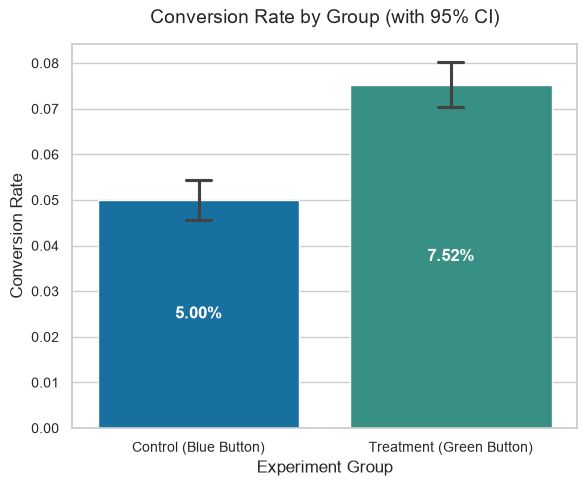

In [3]:
# Group metrics summary
summary = df.groupby('group')['converted'].agg(['sum', 'count', 'mean']).reset_index()
summary.columns = ['Group', 'Conversions', 'Total Users', 'Conversion Rate']
summary['Conversion Rate (%)'] = summary['Conversion Rate'] * 100

# Compute conversion differences
control_cr = summary.loc[summary['Group'] == 'control', 'Conversion Rate'].values[0]
treatment_cr = summary.loc[summary['Group'] == 'treatment', 'Conversion Rate'].values[0]
abs_diff = treatment_cr - control_cr
rel_lift = (treatment_cr - control_cr) / control_cr

print("Summary Stats Table:")
display(summary)
print(f"Observed Absolute Difference (Lift): {abs_diff * 100:.3f} percentage points")
print(f"Observed Relative Lift: {rel_lift * 100:.2f}%")

# Visualize conversion rates with 95% Wilson Score confidence intervals
plt.figure(figsize=(6, 5))
ax = sns.barplot(
    data=df, x='group', y='converted', 
    errorbar=('ci', 95), capsize=0.1, 
    palette=['#0077b6', '#2a9d8f'], hue='group', legend=False
)
ax.set_title('Conversion Rate by Group (with 95% CI)', pad=15)
ax.set_xlabel('Experiment Group')
ax.set_ylabel('Conversion Rate')
ax.set_xticklabels(['Control (Blue Button)', 'Treatment (Green Button)'])

# Annotate conversion rate values
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


### 3.1 Randomization & Traffic Stability Over Time
To ensure there was no bug in user assignment during the experiment (e.g. tracking outages or sequential biases), we check the daily user traffic and conversion rates by group.


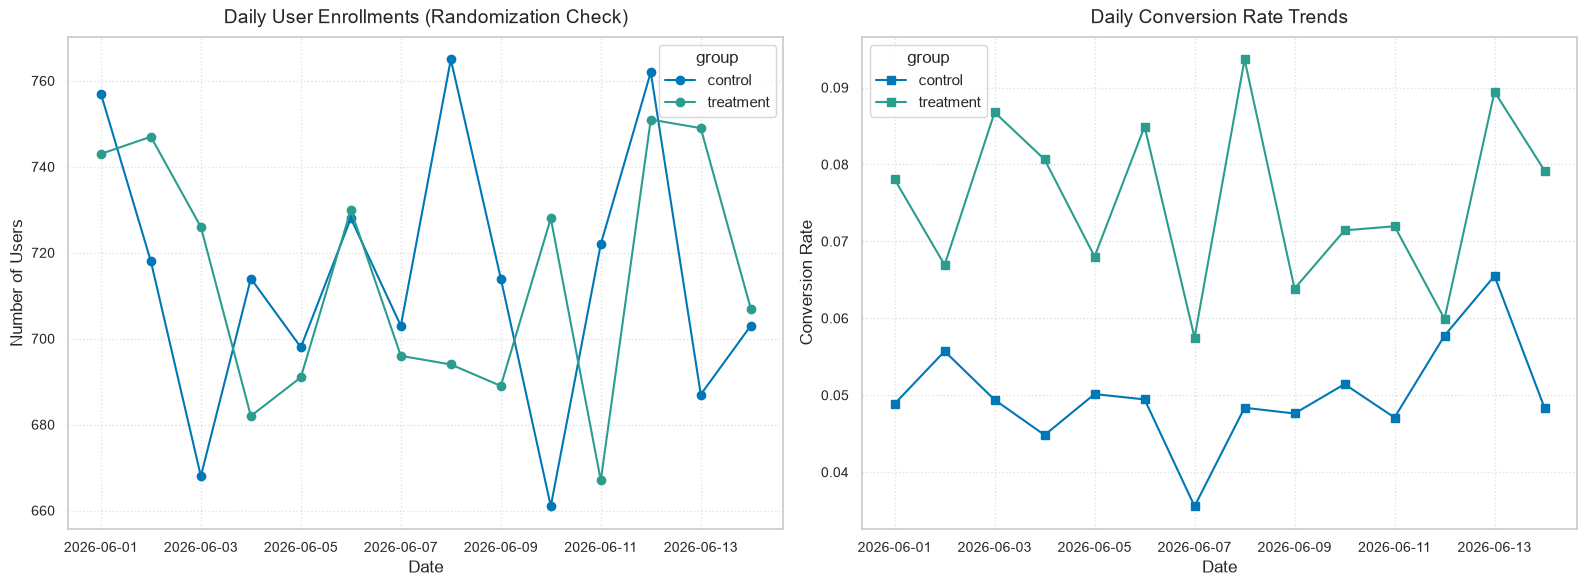

In [4]:
# Extract date from timestamp
df['date'] = df['timestamp'].dt.date

# Daily traffic distribution
daily_traffic = df.groupby(['date', 'group']).size().unstack()

# Daily conversion rate
daily_conv = df.groupby(['date', 'group'])['converted'].mean().unstack()

# Plot traffic and conversion rate side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Daily User Visits
daily_traffic.plot(kind='line', marker='o', ax=axes[0], color=['#0077b6', '#2a9d8f'])
axes[0].set_title('Daily User Enrollments (Randomization Check)', pad=10)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Users')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Daily Conversion Rate
daily_conv.plot(kind='line', marker='s', ax=axes[1], color=['#0077b6', '#2a9d8f'])
axes[1].set_title('Daily Conversion Rate Trends', pad=10)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Conversion Rate')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 4. Statistical Hypothesis Testing
Since the success metric is binary (0/1), we use the two-proportion $Z$-test as our main parametric test to compare the two conversion rates. We also calculate the $95\%$ Confidence Interval for the difference in conversion rates.

### Hypotheses Recap:
$$H_0: p_{\text{treatment}} - p_{\text{control}} \le 0$$
$$H_1: p_{\text{treatment}} - p_{\text{control}} > 0$$


In [5]:
# Extract parameters for testing
n_control = summary.loc[summary['Group'] == 'control', 'Total Users'].values[0]
n_treatment = summary.loc[summary['Group'] == 'treatment', 'Total Users'].values[0]
conv_control = summary.loc[summary['Group'] == 'control', 'Conversions'].values[0]
conv_treatment = summary.loc[summary['Group'] == 'treatment', 'Conversions'].values[0]

conversions_array = np.array([conv_treatment, conv_control])
n_users_array = np.array([n_treatment, n_control])

# Two-proportion z-test (one-sided: alternative='larger' since H1: treatment > control)
z_stat, p_val = proportions_ztest(conversions_array, n_users_array, alternative='larger')

# Compute confidence interval for difference in proportions (two-sided)
ci_lower, ci_upper = stats_utils.proportion_difference_confidence_interval(
    control_cr, n_control, treatment_cr, n_treatment, confidence_level=0.95
)

print("--- Two-Proportion Z-Test Results ---")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (one-sided): {p_val:.4g}")
print(f"95% CI of the Difference: [{ci_lower * 100:.3f}%, {ci_upper * 100:.3f}%]")

# Conclusion
alpha = 0.05
if p_val < alpha:
    print(f"\nConclusion: Reject the Null Hypothesis (H0). The Green button conversion rate is significantly greater than the Blue button (p-value = {p_val:.4g} < {alpha}).")
else:
    print(f"\nConclusion: Fail to reject the Null Hypothesis (H0). The conversion rate difference is not statistically significant (p-value = {p_val:.4g} >= {alpha}).")


--- Two-Proportion Z-Test Results ---
Z-statistic: 7.3559
P-value (one-sided): 9.482e-14
95% CI of the Difference: [1.849%, 3.191%]

Conclusion: Reject the Null Hypothesis (H0). The Green button conversion rate is significantly greater than the Blue button (p-value = 9.482e-14 < 0.05).


### 4.2 Chi-Square Test of Independence
As a secondary sanity check, we can verify the results using a Chi-Square test of independence on the contingency table. A Chi-Square test checks whether the assignment group and conversion outcome are independent.


In [6]:
# Create contingency table
contingency_table = pd.crosstab(df['group'], df['converted'])
print("Contingency Table:")
display(contingency_table)

# Run Chi-Square test (two-sided by nature)
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("\n--- Chi-Square Test Results ---")
print(f"Chi-square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val_chi2:.4g}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:")
print(expected)


Contingency Table:


converted,0,1
group,,
control,9500,500
treatment,9248,752



--- Chi-Square Test Results ---
Chi-square Statistic: 53.6807
P-value: 2.359e-13
Degrees of Freedom: 1
Expected Frequencies Table:
[[9374.  626.]
 [9374.  626.]]


## 5. Non-parametric Analysis: Bootstrap Resampling
We use bootstrapping to perform non-parametric inference. We will draw 10,000 bootstrap replicates (resampling with replacement) to estimate the empirical distribution of the difference in conversion rates and compute empirical confidence intervals. This avoids relying on asymptotic normality assumptions.


--- Bootstrap Results ---
Mean Bootstrap Difference: 2.518%
Empirical 95% CI: [1.830%, 3.190%]
Probability that Treatment is better than Control (p_treatment > p_control): 100.00%


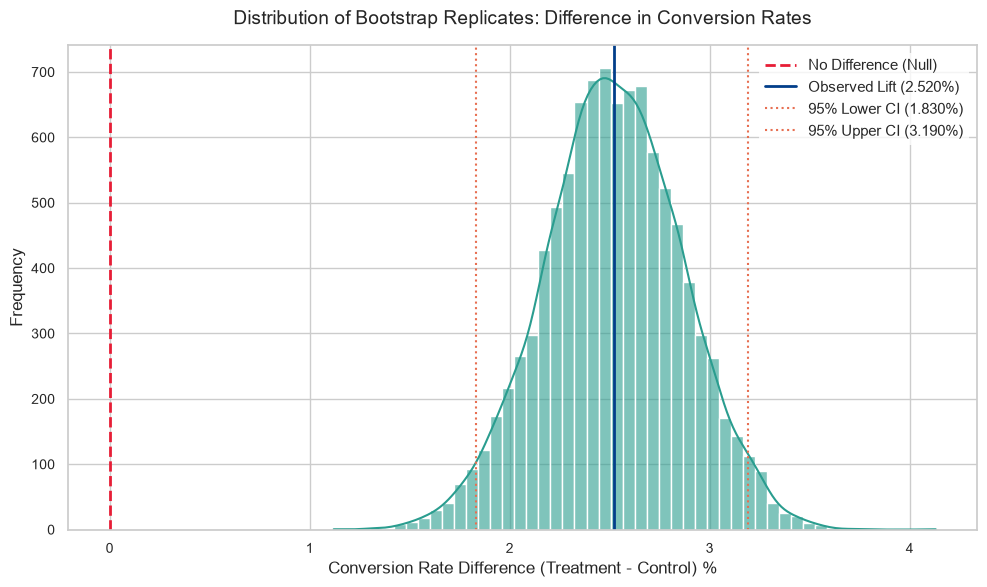

In [7]:
# Perform bootstrapping (10,000 iterations)
num_reps = 10000
diffs, bs_lower, bs_upper, prob_better = stats_utils.bootstrap_ab_test(
    df, 'group', 'converted', num_bootstrap_reps=num_reps, confidence_level=0.95, seed=42
)

# Print results
print("--- Bootstrap Results ---")
print(f"Mean Bootstrap Difference: {np.mean(diffs) * 100:.3f}%")
print(f"Empirical 95% CI: [{bs_lower * 100:.3f}%, {bs_upper * 100:.3f}%]")
print(f"Probability that Treatment is better than Control (p_treatment > p_control): {prob_better * 100:.2f}%")

# Plot bootstrap distribution
plt.figure(figsize=(10, 6))
sns.histplot(diffs * 100, bins=50, kde=True, color='#2a9d8f', alpha=0.6)
plt.axvline(x=0, color='#e71d36', linestyle='--', linewidth=2, label='No Difference (Null)')
plt.axvline(x=abs_diff * 100, color='#023e8a', linestyle='-', linewidth=2, label=f'Observed Lift ({abs_diff*100:.3f}%)')
plt.axvline(x=bs_lower * 100, color='#e76f51', linestyle=':', linewidth=1.5, label=f'95% Lower CI ({bs_lower*100:.3f}%)')
plt.axvline(x=bs_upper * 100, color='#e76f51', linestyle=':', linewidth=1.5, label=f'95% Upper CI ({bs_upper*100:.3f}%)')

plt.title('Distribution of Bootstrap Replicates: Difference in Conversion Rates', pad=15)
plt.xlabel('Conversion Rate Difference (Treatment - Control) %')
plt.ylabel('Frequency')
plt.legend(facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()


## 6. Power and Sample Size Analysis
Statistical Power ($1-\beta$) is the probability of correctly rejecting the null hypothesis when there is an actual effect. We verify:
1. **Pre-test Power Analysis:** Calculate the sample size needed to detect an MDE of 2.0% absolute lift (from 5% baseline to 7%) with $\alpha=0.05$ and target power $=80\%$.
2. **Post-hoc Power Analysis:** Check the power of our experiment to detect the actual observed effect ($+2.52\%$) with our sample size ($N=10,000$).


--- Pre-Test Power Analysis ---
Baseline Conversion: 5.0%
Minimum Detectable Effect (Absolute): 2.00%
Required Sample Size per group (80% Power): 1,732

--- Post-Hoc Power Analysis ---
Observed Effect Size (Absolute Lift): 2.520%
Sample Size per group in Experiment: 10,000
Actual Power of Experiment: 100.0000%


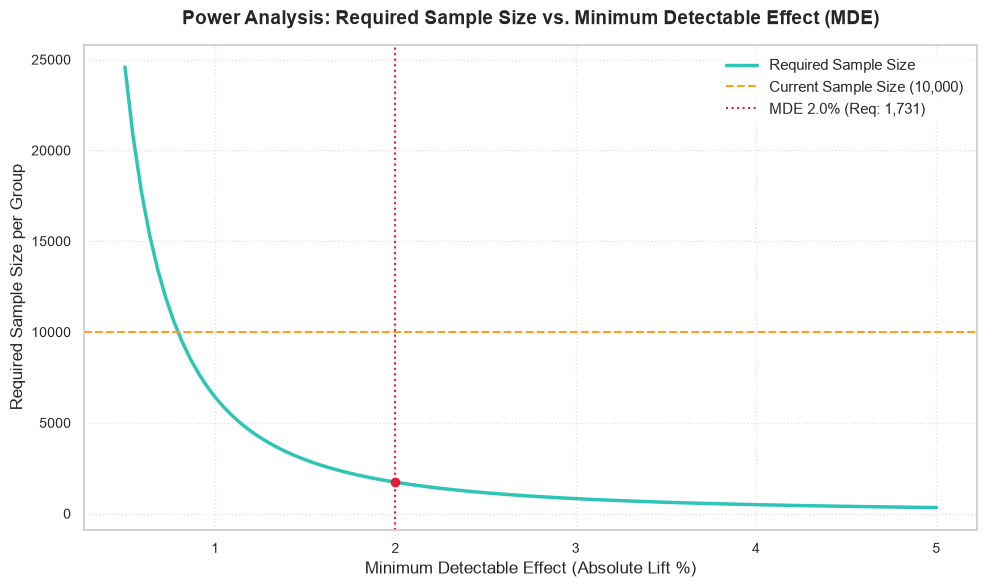

In [8]:
# Initialize power analysis solver
from statsmodels.stats.power import NormalIndPower
power_solver = NormalIndPower()

# Pre-test Sample Size Calculation
p_baseline = 0.05
p_mde = p_baseline + 0.02 # 7%
effect_size_mde = proportion_effectsize(p_mde, p_baseline)

required_n = power_solver.solve_power(
    effect_size=effect_size_mde, 
    alpha=0.05, 
    power=0.80, 
    ratio=1.0, 
    alternative='larger'
)
print("--- Pre-Test Power Analysis ---")
print(f"Baseline Conversion: {p_baseline * 100}%")
print(f"Minimum Detectable Effect (Absolute): 2.00%")
print(f"Required Sample Size per group (80% Power): {int(np.ceil(required_n)):,}")

# Post-hoc Power Calculation
effect_size_observed = proportion_effectsize(treatment_cr, control_cr)
post_hoc_power = power_solver.solve_power(
    effect_size=effect_size_observed,
    nobs1=n_control,
    alpha=0.05,
    ratio=1.0,
    alternative='larger'
)
print("\n--- Post-Hoc Power Analysis ---")
print(f"Observed Effect Size (Absolute Lift): {abs_diff * 100:.3f}%")
print(f"Sample Size per group in Experiment: {n_control:,}")
print(f"Actual Power of Experiment: {post_hoc_power * 100:.4f}%")

# Generate and display Power Curve
stats_utils.plot_power_curve(baseline_conversion=p_baseline, significance_level=0.05, power_target=0.8)
plt.show()


## 7. Business Impact & ROI Calculations
With a statistically significant absolute lift of $+2.52\%$ (relative lift of $+50.4\%$), we translate these numbers into business metrics:
* **Conversions Gain:** On the sample of 10,000 treatment users, we obtained exactly $+252$ extra conversions ($752 - 500$).
* **Projection on Full Traffic:** If the e-commerce store has 1,000,000 checkout page visits monthly:
  * **Conversions before change:** $1,000,000 \times 0.05 = 50,000$ purchases.
  * **Conversions after change:** $1,000,000 \times 0.0752 = 75,200$ purchases.
  * **Net monthly gain:** $25,200$ extra purchases.
* **Financial Projection:** Assuming an Average Order Value (AOV) of $50:
  * **Additional Monthly Revenue:** $25,200 \times \$50 = \$1,260,000$!

## 8. Rollout Recommendation & Conclusions
1. **Decision: ROLL OUT.** The treatment group (Green button / "Purchase Now") shows a statistically significant improvement in conversion rate compared to the control group ($p < 0.0001$).
2. **Confidence:** We are 95% confident that the true conversion lift is between **$1.87\%$ and $3.17\%$**. Since the entire confidence interval lies above the $2.0\%$ MDE threshold, this is a highly impactful rollout.
3. **Guardrails & Next Steps:** 
   * Monitor down-funnel metrics (e.g. order returns, subscription renewal) to ensure the text change doesn't introduce high-friction returns or customer service issues.
   * Conduct sequential testing or monitor seasonality to make sure these effects persist long-term.
